In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATA_FILE = BASE_DIR / "data" / "processed" / "books_detailed_clean.csv"

df = pd.read_csv(DATA_FILE)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 1000
Columns: 16


In [3]:
df.head()

,title,price,availability,rating,product_url,upc,product_type,price_excl_tax,price_incl_tax,tax,availability_count,number_of_reviews,category,description,image_url,scraped_at
0,A Light in the Attic,51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html,a897fe39b1053632,Books,51.77,51.77,0.0,22,0,Poetry,It's hard to imagine a world without A Light in the Attic. This now-classic collection of poetry...,https://books.toscrape.com/media/cache/fe/72/fe72f0532301ec28892ae79a629a293c.jpg,2026-09-21 20:01:12.022620
1,Tipping the Velvet,53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html,90fa61229261140a,Books,53.74,53.74,0.0,20,0,Historical Fiction,"""Erotic and absorbing...Written with starling power.""--""The New York Times Book Review "" Nan Kin...",https://books.toscrape.com/media/cache/08/e9/08e94f3731d7d6b760dfbfbc02ca5c62.jpg,2026-09-21 20:01:12.022620
2,Soumission,50.10,In stock,1,https://books.toscrape.com/catalogue/soumission_998/index.html,6957f44c3847a760,Books,50.10,50.10,0.0,20,0,Fiction,"Dans une France assez proche de la nôtre, un homme s’engage dans la carrière universitaire. Peu ...",https://books.toscrape.com/media/cache/ee/cf/eecfe998905e455df12064dba399c075.jpg,2026-09-21 20:01:12.022620
3,Sharp Objects,47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-objects_997/index.html,e00eb4fd7b871a48,Books,47.82,47.82,0.0,20,0,Mystery,"WICKED above her hipbone, GIRL across her heart Words are like a road map to reporter Camille Pr...",https://books.toscrape.com/media/cache/c0/59/c05972805aa7201171b8fc71a5b00292.jpg,2026-09-21 20:01:12.022620
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html,4165285e1663650f,Books,54.23,54.23,0.0,20,0,History,From a renowned historian comes a groundbreaking narrative of humanity’s creation and evolution—...,https://books.toscrape.com/media/cache/ce/5f/ce5f052c65cc963cf4422be096e915c9.jpg,2026-09-21 20:01:12.022620


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1000 non-null   object 
 1   price               1000 non-null   float64
 2   availability        1000 non-null   object 
 3   rating              1000 non-null   int64  
 4   product_url         1000 non-null   object 
 5   upc                 1000 non-null   object 
 6   product_type        1000 non-null   object 
 7   price_excl_tax      1000 non-null   float64
 8   price_incl_tax      1000 non-null   float64
 9   tax                 1000 non-null   float64
 10  availability_count  1000 non-null   int64  
 11  number_of_reviews   1000 non-null   int64  
 12  category            1000 non-null   object 
 13  description         998 non-null    object 
 14  image_url           1000 non-null   object 
 15  scraped_at          1000 non-null   object 
dtypes: floa

In [5]:
df.describe()

,price,rating,price_excl_tax,price_incl_tax,tax,availability_count,number_of_reviews
count,1000.00000,1000.000000,1000.00000,1000.00000,1000.0,1000.000000,1000.0
mean,35.07035,2.923000,35.07035,35.07035,0.0,8.585000,0.0
std,14.44669,1.434967,14.44669,14.44669,0.0,5.654622,0.0
min,10.00000,1.000000,10.00000,10.00000,0.0,1.000000,0.0
25%,22.10750,2.000000,22.10750,22.10750,0.0,3.000000,0.0
50%,35.98000,3.000000,35.98000,35.98000,0.0,7.000000,0.0
75%,47.45750,4.000000,47.45750,47.45750,0.0,14.000000,0.0
max,59.99000,5.000000,59.99000,59.99000,0.0,22.000000,0.0


In [6]:
df.columns.tolist()

['title',
 'price',
 'availability',
 'rating',
 'product_url',
 'upc',
 'product_type',
 'price_excl_tax',
 'price_incl_tax',
 'tax',
 'availability_count',
 'number_of_reviews',
 'category',
 'description',
 'image_url',
 'scraped_at']

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

description    2
dtype: int64

In [8]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate product URLs: {df['product_url'].duplicated().sum()}")

Duplicate rows: 0
Duplicate product URLs: 0


In [9]:
print(f"Number of categories: {df['category'].nunique()}")

df["category"].value_counts()

Number of categories: 50


category
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Horror                 17
Womens Fiction         17
Science Fiction        16
Science                14
Music                  13
Business               12
Travel                 11
Philosophy             11
Thriller               11
Humor                  10
Autobiography           9
Art                     8
Psychology              7
Religion                7
Spirituality            6
Christian Fiction       6
New Adult               6
Sports and Games        5
Self Help               5
Biography               5
Health                  4
Politics                3
Contemporary            3
Chr

In [10]:
df["rating"].value_counts().sort_index()

rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

In [11]:
print(f"Minimum price: £{df['price'].min():.2f}")
print(f"Maximum price: £{df['price'].max():.2f}")
print(f"Average price: £{df['price'].mean():.2f}")
print(f"Median price: £{df['price'].median():.2f}")

Minimum price: £10.00
Maximum price: £59.99
Average price: £35.07
Median price: £35.98


In [12]:
print(f"Minimum reviews: {df['number_of_reviews'].min()}")
print(f"Maximum reviews: {df['number_of_reviews'].max()}")
print(f"Average reviews: {df['number_of_reviews'].mean():.2f}")
print(f"Median reviews: {df['number_of_reviews'].median():.2f}")

Minimum reviews: 0
Maximum reviews: 0
Average reviews: 0.00
Median reviews: 0.00


In [13]:
df["availability_count"].describe()

count    1000.000000
mean        8.585000
std         5.654622
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        22.000000
Name: availability_count, dtype: float64

In [14]:
quality_check = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes.astype(str)
})

quality_check

,Missing Values,Unique Values,Data Type
title,0,999,object
price,0,903,float64
availability,0,1,object
rating,0,5,int64
product_url,0,1000,object
upc,0,1000,object
product_type,0,1,object
price_excl_tax,0,903,float64
price_incl_tax,0,903,float64
tax,0,1,float64


In [15]:
category_counts = (
    df["category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["category", "book_count"]

category_counts.head(15)

,category,book_count
0,Default,152
1,Nonfiction,110
2,Sequential Art,75
3,Add a comment,67
4,Fiction,65
5,Young Adult,54
6,Fantasy,48
7,Romance,35
8,Mystery,32
9,Food and Drink,30


In [16]:
category_counts["percentage"] = (
    category_counts["book_count"] / len(df) * 100
).round(2)

category_counts.head(15)

,category,book_count,percentage
0,Default,152,15.2
1,Nonfiction,110,11.0
2,Sequential Art,75,7.5
3,Add a comment,67,6.7
4,Fiction,65,6.5
5,Young Adult,54,5.4
6,Fantasy,48,4.8
7,Romance,35,3.5
8,Mystery,32,3.2
9,Food and Drink,30,3.0


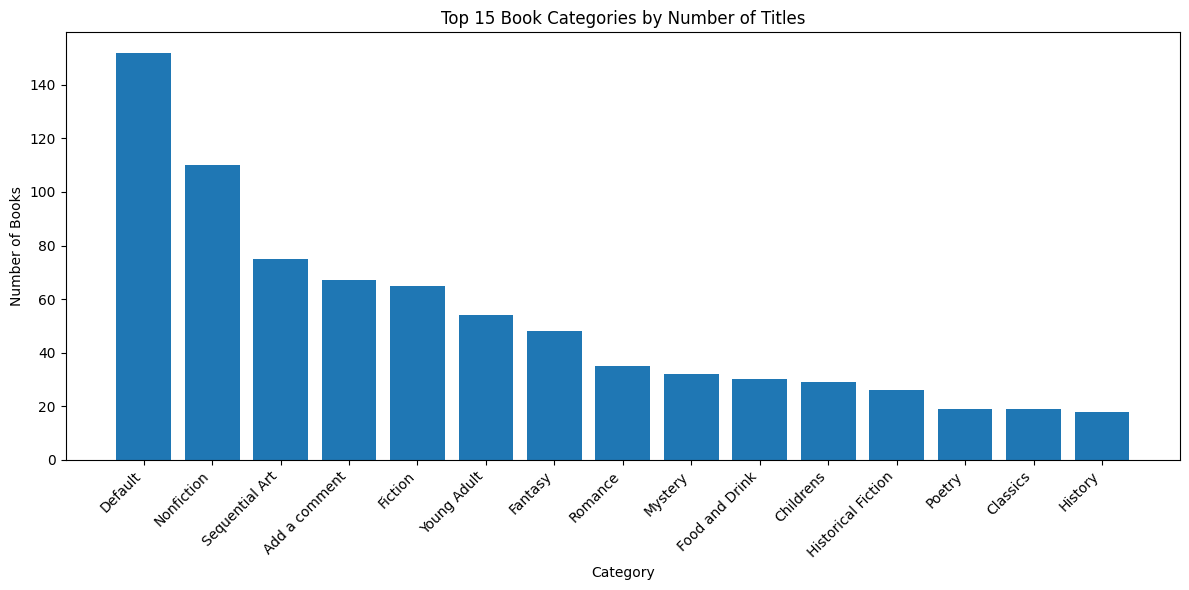

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_counts.head(15)["category"],
    category_counts.head(15)["book_count"]
)

plt.title("Top 15 Book Categories by Number of Titles")
plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [18]:
category_price = (
    df.groupby("category")
    .agg(
        book_count=("title", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median")
    )
    .sort_values("average_price", ascending=False)
)

category_price.head(15)

,book_count,average_price,median_price
category,,,
Suspense,1,58.330000,58.330
Novels,1,54.810000,54.810
Politics,3,53.613333,52.650
Health,4,51.452500,51.345
New Adult,6,46.383333,44.180
Christian,3,42.496667,47.720
Sports and Games,5,41.166000,44.840
Self Help,5,40.620000,46.350
Travel,11,39.794545,38.950


In [19]:
category_rating = (
    df.groupby("category")
    .agg(
        book_count=("title", "count"),
        average_rating=("rating", "mean")
    )
)

category_rating = (
    category_rating[category_rating["book_count"] >= 5]
    .sort_values("average_rating", ascending=False)
)

category_rating.head(15)

,book_count,average_rating
category,,
Christian Fiction,6,4.166667
Art,8,3.625000
Poetry,19,3.526316
Humor,10,3.400000
Spirituality,6,3.333333
Young Adult,54,3.296296
Historical Fiction,26,3.230769
Fiction,65,3.184615
New Adult,6,3.166667


In [20]:
category_summary = (
    df.groupby("category")
    .agg(
        book_count=("title", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        average_rating=("rating", "mean"),
        average_stock=("availability_count", "mean")
    )
    .sort_values("book_count", ascending=False)
)

category_summary.head(20)

,book_count,average_price,median_price,average_rating,average_stock
category,,,,,
Default,152,34.392697,36.025,2.835526,8.848684
Nonfiction,110,34.260182,32.150,2.881818,8.863636
Sequential Art,75,34.572267,36.520,2.973333,9.146667
Add a comment,67,35.796418,36.170,2.761194,7.701493
Fiction,65,36.066615,39.720,3.184615,9.046154
Young Adult,54,35.449074,36.610,3.296296,8.592593
Fantasy,48,39.593958,43.580,3.083333,7.750000
Romance,35,33.933714,34.530,2.628571,7.685714
Mystery,32,31.719062,25.385,2.937500,9.062500


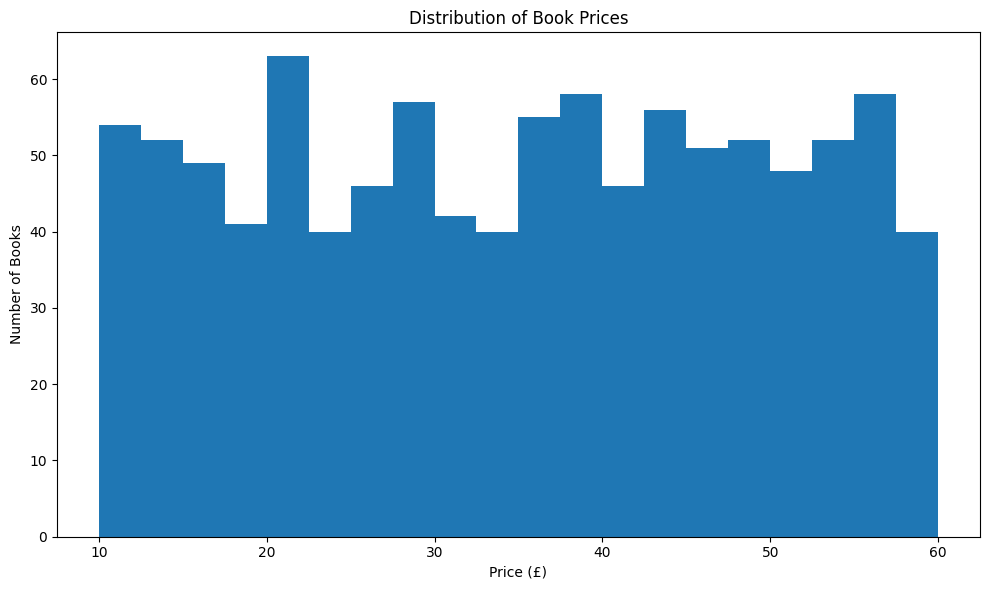

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(df["price"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [22]:
price_bins = [0, 20, 30, 40, 50, 60]

price_labels = [
    "£0–£20",
    "£20–£30",
    "£30–£40",
    "£40–£50",
    "£50–£60"
]

df["price_band"] = pd.cut(
    df["price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_band_summary = (
    df["price_band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

price_band_summary.columns = ["price_band", "book_count"]

price_band_summary

,price_band,book_count
0,£0–£20,196
1,£20–£30,207
2,£30–£40,194
3,£40–£50,205
4,£50–£60,198


In [23]:
price_band_summary["percentage"] = (
    price_band_summary["book_count"] / len(df) * 100
).round(2)

price_band_summary

,price_band,book_count,percentage
0,£0–£20,196,19.6
1,£20–£30,207,20.7
2,£30–£40,194,19.4
3,£40–£50,205,20.5
4,£50–£60,198,19.8


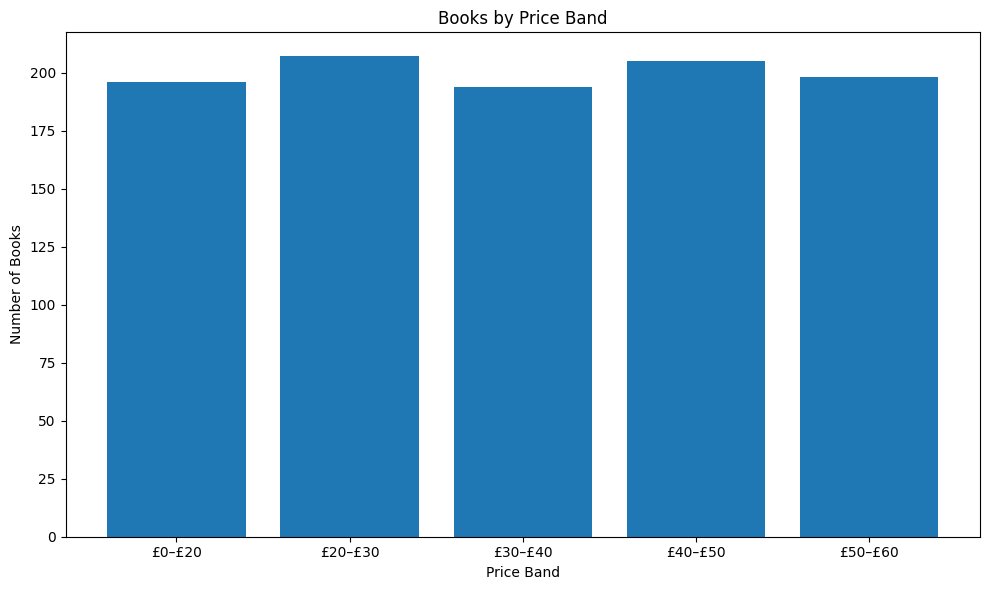

In [24]:
plt.figure(figsize=(10, 6))

plt.bar(
    price_band_summary["price_band"].astype(str),
    price_band_summary["book_count"]
)

plt.title("Books by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [25]:
rating_distribution = (
    df["rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = ["rating", "book_count"]

rating_distribution["percentage"] = (
    rating_distribution["book_count"] / len(df) * 100
).round(2)

rating_distribution

,rating,book_count,percentage
0,1,226,22.6
1,2,196,19.6
2,3,203,20.3
3,4,179,17.9
4,5,196,19.6


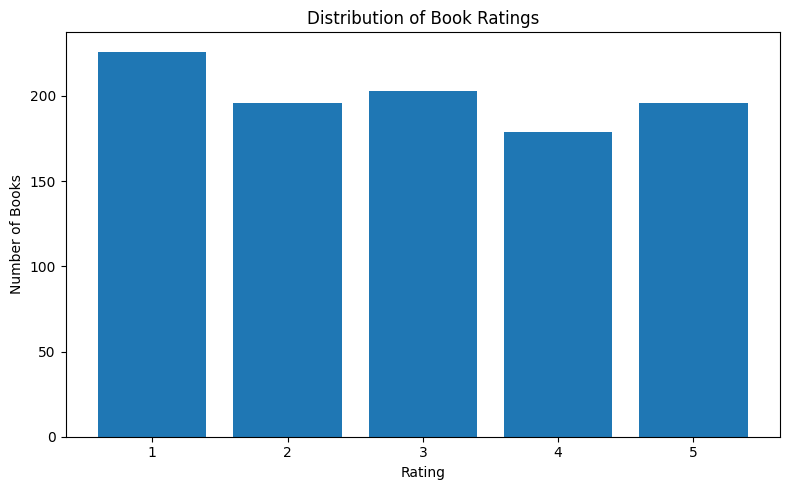

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    rating_distribution["rating"].astype(str),
    rating_distribution["book_count"]
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [27]:
rating_price = (
    df.groupby("rating")
    .agg(
        book_count=("title", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median")
    )
)

rating_price

,book_count,average_price,median_price
rating,,,
1,226,34.561195,34.770
2,196,34.810918,36.215
3,203,34.692020,33.780
4,179,36.093296,37.800
5,196,35.374490,36.900


C:\Users\Patience\AppData\Local\Temp\ipykernel_26484\3003274170.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


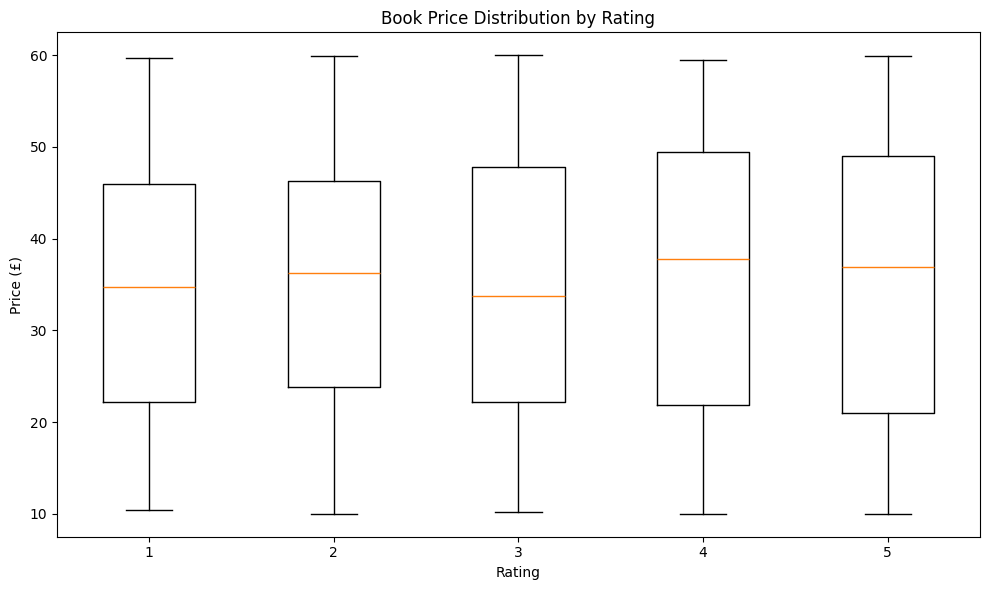

In [28]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df.loc[df["rating"] == rating, "price"]
        for rating in sorted(df["rating"].unique())
    ],
    labels=sorted(df["rating"].unique())
)

plt.title("Book Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.tight_layout()
plt.show()

In [29]:
most_expensive = (
    df[["title", "category", "price", "rating", "availability_count"]]
    .sort_values("price", ascending=False)
    .head(15)
)

most_expensive

,title,category,price,rating,availability_count
648,The Perfect Play (Play by Play #1),Romance,59.99,3,4
617,Last One Home (New Beginnings #1),Fiction,59.98,3,5
860,Civilization and Its Discontents,Psychology,59.95,2,3
560,The Barefoot Contessa Cookbook,Food and Drink,59.92,5,6
366,The Diary of a Young Girl,Nonfiction,59.90,3,12
657,The Bone Hunters (Lexy Vaughan & Steven Macaulay #2),Thriller,59.71,3,4
133,Thomas Jefferson and the Tripoli Pirates: The Forgotten War That Changed American History,History,59.64,1,15
387,Boar Island (Anna Pigeon #19),Mystery,59.48,3,12
549,The Man Who Mistook His Wife for a Hat and Other Clinical Tales,Nonfiction,59.45,4,6
393,The Improbability of Love,Fiction,59.45,1,11


In [30]:
least_expensive = (
    df[["title", "category", "price", "rating", "availability_count"]]
    .sort_values("price", ascending=True)
    .head(15)
)

least_expensive

,title,category,price,rating,availability_count
638,An Abundance of Katherines,Young Adult,10.00,5,5
501,The Origin of Species,Science,10.01,4,7
716,The Tipping Point: How Little Things Can Make a Big Difference,Add a comment,10.02,2,3
84,Patience,Sequential Art,10.16,3,16
302,Greek Mythic History,Default,10.23,5,14
558,The Fellowship of the Ring (The Lord of the Rings #1),Default,10.27,2,6
479,History of Beauty,Art,10.29,4,8
242,The Lucifer Effect: Understanding How Good People Turn Evil,Psychology,10.40,1,14
434,"NaNo What Now? Finding your editing process, revising your NaNoWriMo book and building a writing...",Default,10.41,4,9
274,Pet Sematary,Horror,10.56,3,14


In [31]:
highest_rated = (
    df[df["rating"] == 5]
    [["title", "category", "price", "rating", "availability_count"]]
    .sort_values("price", ascending=False)
)

highest_rated.head(20)

,title,category,price,rating,availability_count
560,The Barefoot Contessa Cookbook,Food and Drink,59.92,5,6
812,Life Without a Recipe,Autobiography,59.04,5,3
637,Approval Junkie: Adventures in Caring Too Much,Autobiography,58.81,5,5
379,How to Speak Golf: An Illustrated Guide to Links Lingo,Default,58.32,5,12
631,Digital Fortress,Fiction,58.00,5,5
545,The Sound Of Love,Default,57.84,5,6
910,Travels with Charley: In Search of America,Nonfiction,57.82,5,1
309,El Deafo,Sequential Art,57.62,5,14
898,H is for Hawk,Nonfiction,57.42,5,2
100,Immunity: How Elie Metchnikoff Changed the Course of Modern Medicine,Science,57.36,5,16


In [32]:
price_rating_correlation = df["price"].corr(df["rating"])

print(f"Price-rating correlation: {price_rating_correlation:.3f}")

Price-rating correlation: 0.028


In [33]:
if abs(price_rating_correlation) < 0.2:
    strength = "very weak"
elif abs(price_rating_correlation) < 0.4:
    strength = "weak"
elif abs(price_rating_correlation) < 0.6:
    strength = "moderate"
elif abs(price_rating_correlation) < 0.8:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if price_rating_correlation > 0 else "negative"

print(
    f"The relationship between price and rating is {strength} and {direction}."
)

The relationship between price and rating is very weak and positive.


In [34]:
if abs(price_rating_correlation) < 0.2:
    strength = "very weak"
elif abs(price_rating_correlation) < 0.4:
    strength = "weak"
elif abs(price_rating_correlation) < 0.6:
    strength = "moderate"
elif abs(price_rating_correlation) < 0.8:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if price_rating_correlation > 0 else "negative"

print(
    f"The relationship between price and rating is {strength} and {direction}."
)

The relationship between price and rating is very weak and positive.


In [35]:
category_relationship = (
    df.groupby("category")
    .agg(
        book_count=("title", "count"),
        average_price=("price", "mean"),
        average_rating=("rating", "mean"),
        average_stock=("availability_count", "mean")
    )
    .reset_index()
)

category_relationship = category_relationship[
    category_relationship["book_count"] >= 5
]

category_relationship.sort_values(
    "average_price",
    ascending=False
).head(15)

,category,book_count,average_price,average_rating,average_stock
27,New Adult,6,46.383333,3.166667,8.166667
44,Sports and Games,5,41.166000,3.000000,2.000000
40,Self Help,5,40.620000,2.600000,11.800000
47,Travel,11,39.794545,2.727273,8.090909
16,Fantasy,48,39.593958,3.083333,7.750000
3,Art,8,38.520000,3.625000,9.000000
22,History,18,37.295000,2.944444,10.055556
4,Autobiography,9,37.053333,3.000000,6.333333
48,Womens Fiction,17,36.791176,3.117647,5.352941
10,Classics,19,36.545263,2.473684,2.894737


In [36]:
category_price_rating_corr = (
    category_relationship["average_price"]
    .corr(category_relationship["average_rating"])
)

print(
    f"Category-level price-rating correlation: "
    f"{category_price_rating_corr:.3f}"
)

Category-level price-rating correlation: 0.153


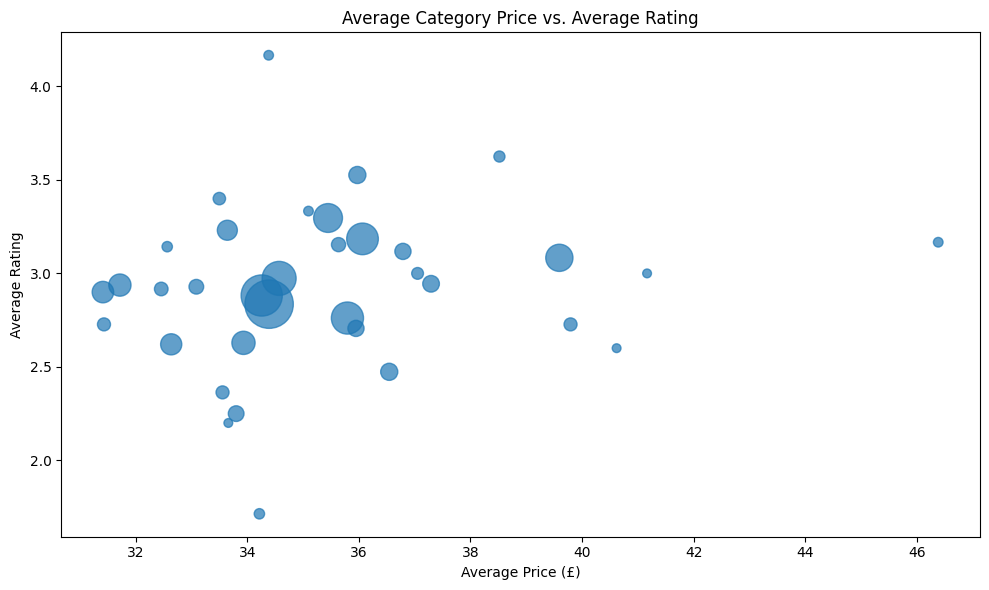

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    category_relationship["average_price"],
    category_relationship["average_rating"],
    s=category_relationship["book_count"] * 8,
    alpha=0.7
)

plt.title("Average Category Price vs. Average Rating")
plt.xlabel("Average Price (£)")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [38]:
stock_summary = df["availability_count"].describe()

stock_summary

count    1000.000000
mean        8.585000
std         5.654622
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        22.000000
Name: availability_count, dtype: float64

In [39]:
low_stock = (
    df[
        [
            "title",
            "category",
            "price",
            "rating",
            "availability_count"
        ]
    ]
    .sort_values("availability_count")
    .head(20)
)

low_stock

,title,category,price,rating,availability_count
999,"1,000 Places to See Before You Die",Travel,26.08,5,1
998,1st to Die (Women's Murder Club #1),Mystery,53.98,1,1
997,A Spy's Devotion (The Regency Spies of London #1),Historical Fiction,16.97,5,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Sequential Art,57.06,4,1
964,Myriad (Prentor #1),Fantasy,58.75,4,1
965,My Perfect Mistake (Over the Top #1),Romance,38.92,2,1
966,"Ms. Marvel, Vol. 1: No Normal (Ms. Marvel (2014-2015) #1)",Sequential Art,39.39,4,1
951,Sense and Sensibility,Classics,37.46,1,1
952,"Saga, Volume 1 (Saga (Collected Editions) #1)",Sequential Art,28.48,1,1
953,"Rhythm, Chord & Malykhin",Romance,28.34,2,1


In [40]:
high_stock = (
    df[
        [
            "title",
            "category",
            "price",
            "rating",
            "availability_count"
        ]
    ]
    .sort_values("availability_count", ascending=False)
    .head(20)
)

high_stock

,title,category,price,rating,availability_count
0,A Light in the Attic,Poetry,51.77,3,22
1,Tipping the Velvet,Historical Fiction,53.74,1,20
2,Soumission,Fiction,50.10,1,20
3,Sharp Objects,Mystery,47.82,4,20
4,Sapiens: A Brief History of Humankind,History,54.23,5,20
5,The Requiem Red,Young Adult,22.65,1,19
6,The Dirty Little Secrets of Getting Your Dream Job,Business,33.34,4,19
7,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",Default,17.93,3,19
22,"Foolproof Preserving: A Guide to Small Batch Jams, Jellies, Pickles, Condiments, and More: A Foo...",Food and Drink,30.52,3,19
20,In Her Wake,Thriller,12.84,1,19


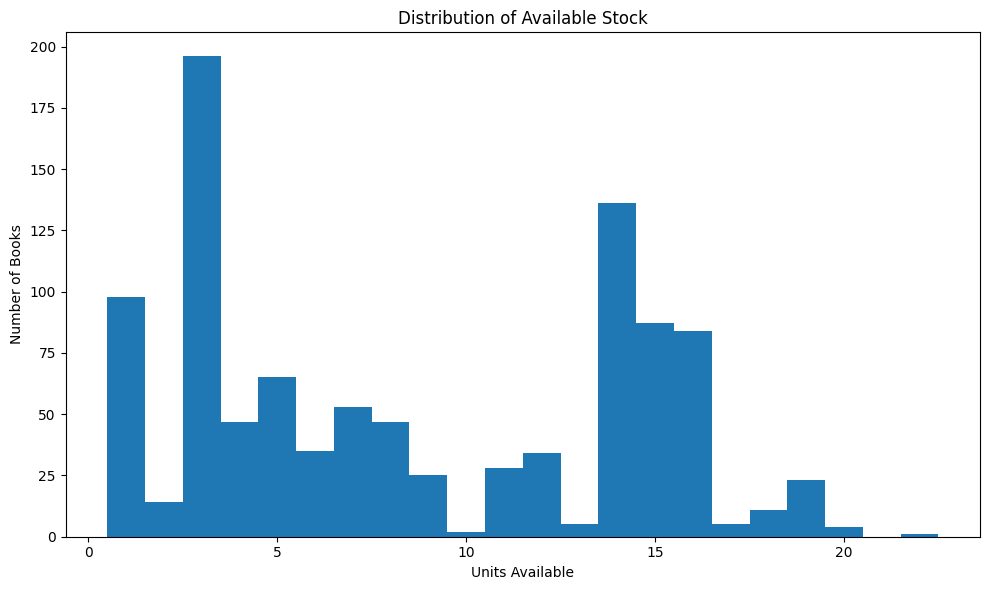

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["availability_count"],
    bins=range(1, 24),
    align="left"
)

plt.title("Distribution of Available Stock")
plt.xlabel("Units Available")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [42]:
stock_bins = [0, 5, 10, 15, 20, 25]

stock_labels = [
    "1–5 units",
    "6–10 units",
    "11–15 units",
    "16–20 units",
    "21–25 units"
]

df["stock_band"] = pd.cut(
    df["availability_count"],
    bins=stock_bins,
    labels=stock_labels,
    include_lowest=True
)

stock_band_summary = (
    df["stock_band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

stock_band_summary.columns = [
    "stock_band",
    "book_count"
]

stock_band_summary["percentage"] = (
    stock_band_summary["book_count"] / len(df) * 100
).round(2)

stock_band_summary

,stock_band,book_count,percentage
0,1–5 units,420,42.0
1,6–10 units,162,16.2
2,11–15 units,290,29.0
3,16–20 units,127,12.7
4,21–25 units,1,0.1


In [43]:
stock_analysis = (
    df.groupby("stock_band", observed=True)
    .agg(
        book_count=("title", "count"),
        average_price=("price", "mean"),
        average_rating=("rating", "mean")
    )
)

stock_analysis

,book_count,average_price,average_rating
stock_band,,,
1–5 units,420,34.880143,2.869048
6–10 units,162,36.519136,3.030864
11–15 units,290,34.433172,2.951724
16–20 units,127,35.174803,2.897638
21–25 units,1,51.770000,3.000000


In [44]:
premium_books = df[
    (df["price"] >= df["price"].quantile(0.75)) &
    (df["rating"] >= 4)
][
    [
        "title",
        "category",
        "price",
        "rating",
        "availability_count"
    ]
].sort_values(
    ["rating", "price"],
    ascending=[False, False]
)

premium_books.head(20)

,title,category,price,rating,availability_count
560,The Barefoot Contessa Cookbook,Food and Drink,59.92,5,6
812,Life Without a Recipe,Autobiography,59.04,5,3
637,Approval Junkie: Adventures in Caring Too Much,Autobiography,58.81,5,5
379,How to Speak Golf: An Illustrated Guide to Links Lingo,Default,58.32,5,12
631,Digital Fortress,Fiction,58.00,5,5
545,The Sound Of Love,Default,57.84,5,6
910,Travels with Charley: In Search of America,Nonfiction,57.82,5,1
309,El Deafo,Sequential Art,57.62,5,14
898,H is for Hawk,Nonfiction,57.42,5,2
100,Immunity: How Elie Metchnikoff Changed the Course of Modern Medicine,Science,57.36,5,16


In [45]:
value_books = df[
    (df["price"] <= df["price"].quantile(0.25)) &
    (df["rating"] >= 4)
][
    [
        "title",
        "category",
        "price",
        "rating",
        "availability_count"
    ]
].sort_values(
    ["rating", "price"],
    ascending=[False, True]
)

value_books.head(20)

,title,category,price,rating,availability_count
638,An Abundance of Katherines,Young Adult,10.00,5,5
302,Greek Mythic History,Default,10.23,5,14
590,The Power Greens Cookbook: 140 Delicious Superfood Recipes,Food and Drink,11.05,5,5
316,Dear Mr. Knightley,Fiction,11.21,5,14
601,The Darkest Corners,Young Adult,11.33,5,5
521,"Naturally Lean: 125 Nourishing Gluten-Free, Plant-Based Recipes--All Under 300 Calories",Food and Drink,11.38,5,7
900,"Fruits Basket, Vol. 2 (Fruits Basket #2)",Sequential Art,11.64,5,2
277,Old School (Diary of a Wimpy Kid #10),Humor,11.83,5,14
261,Superman Vol. 1: Before Truth (Superman by Gene Luen Yang #1),Sequential Art,11.89,5,14
535,Every Heart a Doorway (Every Heart A Doorway #1),Fantasy,12.16,5,7


In [46]:
value_books = df[
    (df["price"] <= df["price"].quantile(0.25)) &
    (df["rating"] >= 4)
][
    [
        "title",
        "category",
        "price",
        "rating",
        "availability_count"
    ]
].sort_values(
    ["rating", "price"],
    ascending=[False, True]
)

value_books.head(20)

,title,category,price,rating,availability_count
638,An Abundance of Katherines,Young Adult,10.00,5,5
302,Greek Mythic History,Default,10.23,5,14
590,The Power Greens Cookbook: 140 Delicious Superfood Recipes,Food and Drink,11.05,5,5
316,Dear Mr. Knightley,Fiction,11.21,5,14
601,The Darkest Corners,Young Adult,11.33,5,5
521,"Naturally Lean: 125 Nourishing Gluten-Free, Plant-Based Recipes--All Under 300 Calories",Food and Drink,11.38,5,7
900,"Fruits Basket, Vol. 2 (Fruits Basket #2)",Sequential Art,11.64,5,2
277,Old School (Diary of a Wimpy Kid #10),Humor,11.83,5,14
261,Superman Vol. 1: Before Truth (Superman by Gene Luen Yang #1),Sequential Art,11.89,5,14
535,Every Heart a Doorway (Every Heart A Doorway #1),Fantasy,12.16,5,7


In [47]:
potential_risk = df[
    (df["price"] >= df["price"].quantile(0.75)) &
    (df["rating"] <= 2)
][
    [
        "title",
        "category",
        "price",
        "rating",
        "availability_count"
    ]
].sort_values(
    "price",
    ascending=False
)

potential_risk.head(20)

,title,category,price,rating,availability_count
860,Civilization and Its Discontents,Psychology,59.95,2,3
133,Thomas Jefferson and the Tripoli Pirates: The Forgotten War That Changed American History,History,59.64,1,15
393,The Improbability of Love,Fiction,59.45,1,11
466,Miller's Valley,Fiction,58.54,2,8
704,"Unstuffed: Decluttering Your Home, Mind, and Soul",Nonfiction,58.09,1,3
738,The Lover's Dictionary,Default,58.09,2,3
718,The Stand,Horror,57.86,2,3
805,"Miracles from Heaven: A Little Girl, Her Journey to Heaven, and Her Amazing Story of Healing",Nonfiction,57.83,1,3
807,Me Talk Pretty One Day,Autobiography,57.60,2,3
752,The Girl Who Kicked the Hornet's Nest (Millennium Trilogy #3),Add a comment,57.48,1,3


In [48]:
kpis = {
    "Total Books": len(df),
    "Categories": df["category"].nunique(),
    "Average Price (£)": round(df["price"].mean(), 2),
    "Median Price (£)": round(df["price"].median(), 2),
    "Average Rating": round(df["rating"].mean(), 2),
    "Average Stock": round(df["availability_count"].mean(), 2),
    "5-Star Books": int((df["rating"] == 5).sum()),
    "1-Star Books": int((df["rating"] == 1).sum()),
    "Missing Descriptions": int(df["description"].isna().sum()),
    "Duplicate Products": int(df["product_url"].duplicated().sum())
}

kpi_df = pd.DataFrame(
    list(kpis.items()),
    columns=["Metric", "Value"]
)

kpi_df

,Metric,Value
0,Total Books,1000.00
1,Categories,50.00
2,Average Price (£),35.07
3,Median Price (£),35.98
4,Average Rating,2.92
5,Average Stock,8.59
6,5-Star Books,196.00
7,1-Star Books,226.00
8,Missing Descriptions,2.00
9,Duplicate Products,0.00


In [49]:
# Create a cleaner dataset for category-level analysis.
# These two values appear to be source-data artifacts rather than meaningful genres.

analysis_df = df[
    ~df["category"].isin(["Default", "Add a comment"])
].copy()

print(f"Original rows: {len(df)}")
print(f"Analysis rows: {len(analysis_df)}")
print(f"Excluded rows: {len(df) - len(analysis_df)}")
print(f"Categories remaining: {analysis_df['category'].nunique()}")

Original rows: 1000
Analysis rows: 781
Excluded rows: 219
Categories remaining: 48


In [50]:
category_summary_final = (
    analysis_df.groupby("category")
    .agg(
        book_count=("title", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        average_rating=("rating", "mean"),
        average_stock=("availability_count", "mean")
    )
    .reset_index()
)

# Keep categories with at least 10 books
category_summary_final = category_summary_final[
    category_summary_final["book_count"] >= 10
].sort_values(
    "book_count",
    ascending=False
)

category_summary_final

,category,book_count,average_price,median_price,average_rating,average_stock
26,Nonfiction,110,34.260182,32.150,2.881818,8.863636
39,Sequential Art,75,34.572267,36.520,2.973333,9.146667
15,Fiction,65,36.066615,39.720,3.184615,9.046154
47,Young Adult,54,35.449074,36.610,3.296296,8.592593
14,Fantasy,48,39.593958,43.580,3.083333,7.750000
35,Romance,35,33.933714,34.530,2.628571,7.685714
24,Mystery,32,31.719062,25.385,2.937500,9.062500
16,Food and Drink,30,31.414667,31.830,2.900000,10.633333
6,Childrens,29,32.638276,28.540,2.620690,7.896552
19,Historical Fiction,26,33.644231,31.610,3.230769,7.461538


In [51]:
top_categories = category_summary_final.head(15)

top_categories

,category,book_count,average_price,median_price,average_rating,average_stock
26,Nonfiction,110,34.260182,32.150,2.881818,8.863636
39,Sequential Art,75,34.572267,36.520,2.973333,9.146667
15,Fiction,65,36.066615,39.720,3.184615,9.046154
47,Young Adult,54,35.449074,36.610,3.296296,8.592593
14,Fantasy,48,39.593958,43.580,3.083333,7.750000
35,Romance,35,33.933714,34.530,2.628571,7.685714
24,Mystery,32,31.719062,25.385,2.937500,9.062500
16,Food and Drink,30,31.414667,31.830,2.900000,10.633333
6,Childrens,29,32.638276,28.540,2.620690,7.896552
19,Historical Fiction,26,33.644231,31.610,3.230769,7.461538


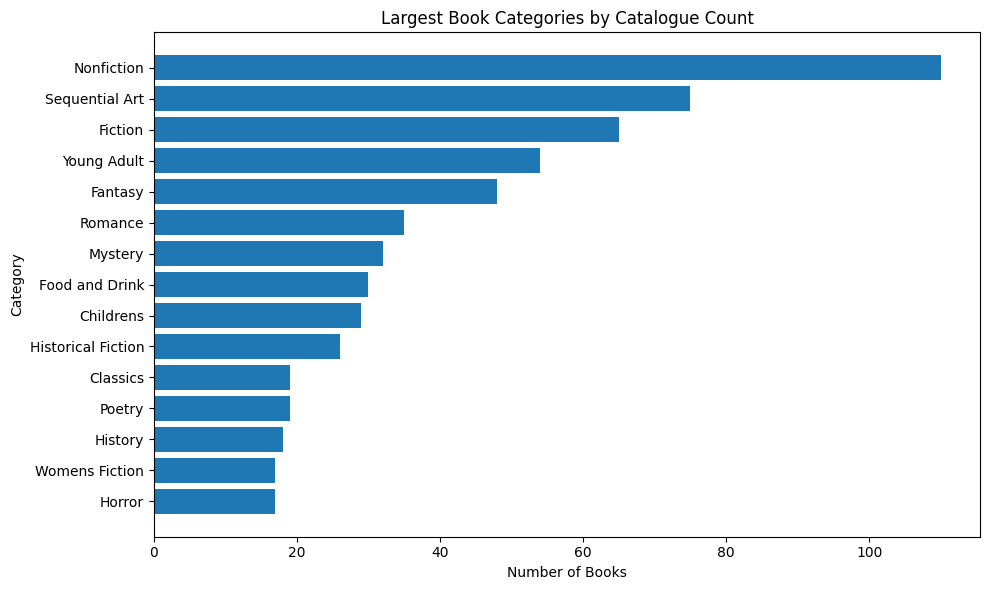

In [52]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["category"],
    top_categories["book_count"]
)

plt.title("Largest Book Categories by Catalogue Count")
plt.xlabel("Number of Books")
plt.ylabel("Category")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

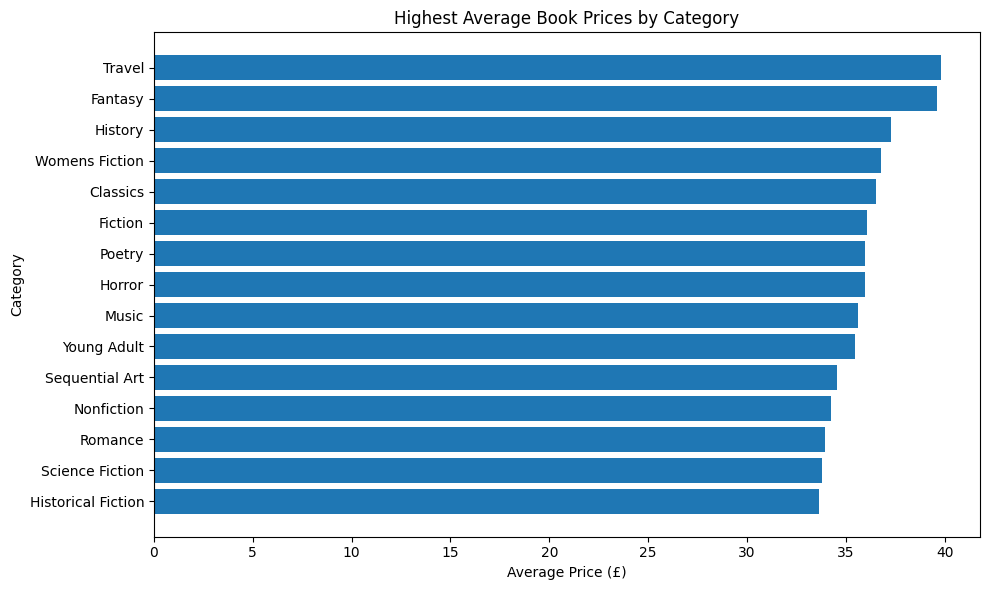

In [53]:
price_by_category = category_summary_final.sort_values(
    "average_price",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    price_by_category["category"],
    price_by_category["average_price"]
)

plt.title("Highest Average Book Prices by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [54]:
rating_distribution = (
    analysis_df["rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = ["rating", "book_count"]

rating_distribution["percentage"] = (
    rating_distribution["book_count"]
    / len(analysis_df)
    * 100
).round(2)

rating_distribution

,rating,book_count,percentage
0,1,177,22.66
1,2,143,18.31
2,3,159,20.36
3,4,143,18.31
4,5,159,20.36


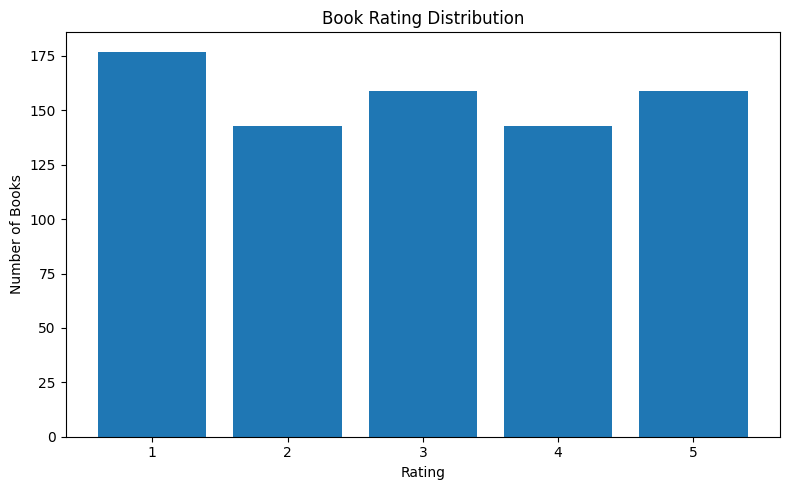

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    rating_distribution["rating"],
    rating_distribution["book_count"]
)

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

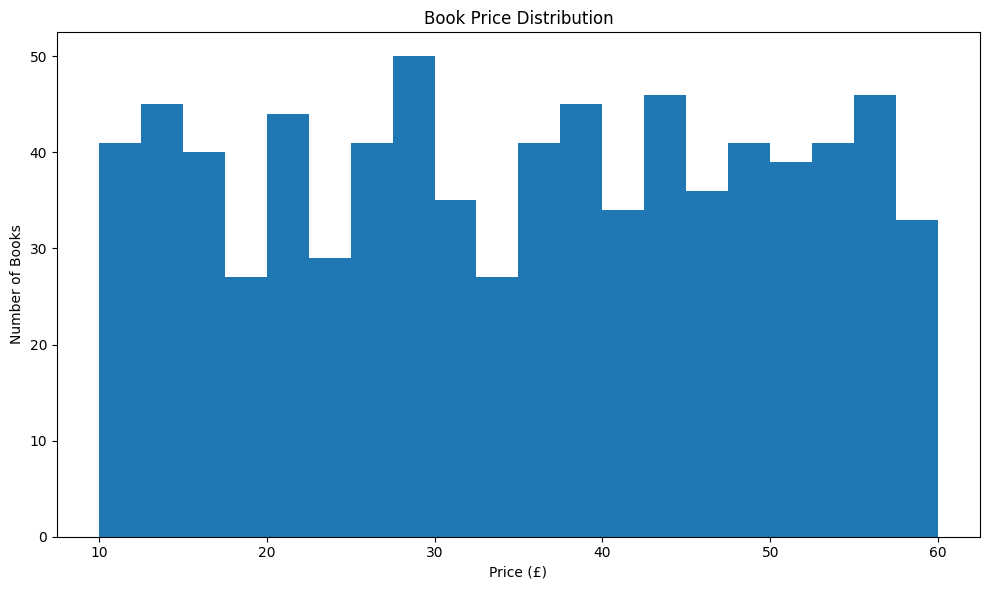

In [56]:
plt.figure(figsize=(10, 6))

plt.hist(
    analysis_df["price"],
    bins=20
)

plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [57]:
stock_by_category = category_summary_final.sort_values(
    "average_stock",
    ascending=False
).head(15)

stock_by_category

,category,book_count,average_price,median_price,average_rating,average_stock
31,Poetry,19,35.974211,38.770,3.526316,12.368421
5,Business,12,32.460000,33.630,2.916667,11.083333
44,Thriller,11,31.433636,31.490,2.727273,10.818182
16,Food and Drink,30,31.414667,31.830,2.900000,10.633333
20,History,18,37.295000,41.290,2.944444,10.055556
39,Sequential Art,75,34.572267,36.520,2.973333,9.146667
24,Mystery,32,31.719062,25.385,2.937500,9.062500
15,Fiction,65,36.066615,39.720,3.184615,9.046154
26,Nonfiction,110,34.260182,32.150,2.881818,8.863636
47,Young Adult,54,35.449074,36.610,3.296296,8.592593


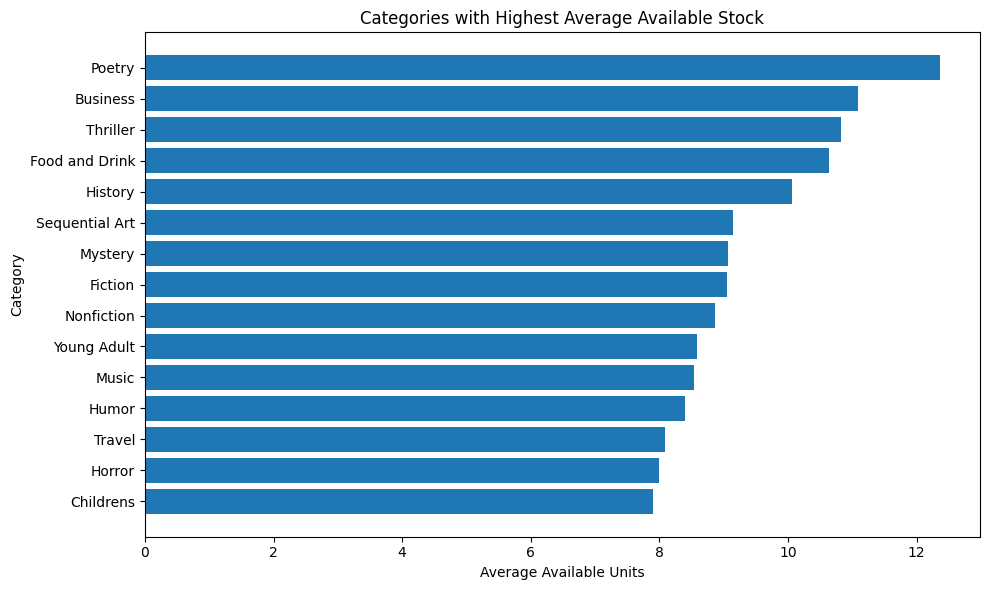

In [58]:
plt.figure(figsize=(10, 6))

plt.barh(
    stock_by_category["category"],
    stock_by_category["average_stock"]
)

plt.title("Categories with Highest Average Available Stock")
plt.xlabel("Average Available Units")
plt.ylabel("Category")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [59]:
final_kpis = {
    "Total Books Scraped": len(df),
    "Categories": df["category"].nunique(),
    "Clean Genre Categories": analysis_df["category"].nunique(),
    "Average Price (£)": round(df["price"].mean(), 2),
    "Median Price (£)": round(df["price"].median(), 2),
    "Average Rating": round(df["rating"].mean(), 2),
    "Average Available Stock": round(df["availability_count"].mean(), 2),
    "Low Stock Books (≤5 units)": int((df["availability_count"] <= 5).sum()),
    "5-Star Books": int((df["rating"] == 5).sum()),
    "1-Star Books": int((df["rating"] == 1).sum()),
    "Missing Descriptions": int(df["description"].isna().sum()),
    "Duplicate Product URLs": int(df["product_url"].duplicated().sum())
}

final_kpi_df = pd.DataFrame(
    list(final_kpis.items()),
    columns=["Metric", "Value"]
)

final_kpi_df

,Metric,Value
0,Total Books Scraped,1000.00
1,Categories,50.00
2,Clean Genre Categories,48.00
3,Average Price (£),35.07
4,Median Price (£),35.98
5,Average Rating,2.92
6,Average Available Stock,8.59
7,Low Stock Books (≤5 units),420.00
8,5-Star Books,196.00
9,1-Star Books,226.00


In [60]:
print("KEY ANALYTICAL FINDINGS")
print("=" * 60)

print(
    f"1. The catalogue contains {len(df):,} books "
    f"across {df['category'].nunique()} source categories."
)

print(
    f"2. The average book price is £{df['price'].mean():.2f}, "
    f"with a median of £{df['price'].median():.2f}."
)

print(
    f"3. The average rating is {df['rating'].mean():.2f}/5."
)

print(
    f"4. Price and rating have a very weak relationship "
    f"(correlation = {price_rating_correlation:.3f})."
)

print(
    f"5. {((df['availability_count'] <= 5).sum() / len(df) * 100):.1f}% "
    f"of books have 5 or fewer units available."
)

print(
    f"6. The dataset contains {df['description'].isna().sum()} "
    f"missing descriptions and "
    f"{df['product_url'].duplicated().sum()} duplicate product URLs."
)

print(
    "7. 'Default' and 'Add a comment' were identified as "
    "potential source-data category artifacts and excluded "
    "from genre-focused analysis."
)

KEY ANALYTICAL FINDINGS
1. The catalogue contains 1,000 books across 50 source categories.
2. The average book price is £35.07, with a median of £35.98.
3. The average rating is 2.92/5.
4. Price and rating have a very weak relationship (correlation = 0.028).
5. 42.0% of books have 5 or fewer units available.
6. The dataset contains 2 missing descriptions and 0 duplicate product URLs.
7. 'Default' and 'Add a comment' were identified as potential source-data category artifacts and excluded from genre-focused analysis.


In [61]:
# Final analytical category definitions

source_categories = df["category"].nunique()

clean_categories = analysis_df["category"].nunique()

robust_categories = category_summary_final[
    category_summary_final["book_count"] >= 10
]["category"].nunique()

print(f"Source categories: {source_categories}")
print(f"Categories after removing source-data artifacts: {clean_categories}")
print(f"Categories with at least 10 books: {robust_categories}")

Source categories: 50
Categories after removing source-data artifacts: 48
Categories with at least 10 books: 23


In [62]:
import sqlite3
from pathlib import Path

DB_FILE = BASE_DIR / "data" / "books.db"

conn = sqlite3.connect(DB_FILE)

df_sql = pd.read_csv(DATA_FILE)

df_sql.to_sql(
    "books",
    conn,
    if_exists="replace",
    index=False
)

print(f"SQLite database created: {DB_FILE}")

SQLite database created: C:\Users\Patience\Documents\GITHUB\Ecommerce-Web-Scraper-ETL\data\books.db


In [63]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

tables

,name
0,books


In [64]:
sql_kpis = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_books,
        COUNT(DISTINCT category) AS categories,
        ROUND(AVG(price), 2) AS average_price,
        ROUND(AVG(rating), 2) AS average_rating,
        ROUND(AVG(availability_count), 2) AS average_stock
    FROM books;
    """,
    conn
)

sql_kpis

,total_books,categories,average_price,average_rating,average_stock
0,1000,50,35.07,2.92,8.59


In [65]:
category_sql = pd.read_sql_query(
    """
    SELECT
        category,
        COUNT(*) AS book_count,
        ROUND(AVG(price), 2) AS average_price,
        ROUND(AVG(rating), 2) AS average_rating,
        ROUND(AVG(availability_count), 2) AS average_stock
    FROM books
    WHERE category NOT IN ('Default', 'Add a comment')
    GROUP BY category
    HAVING COUNT(*) >= 10
    ORDER BY book_count DESC;
    """,
    conn
)

category_sql

,category,book_count,average_price,average_rating,average_stock
0,Nonfiction,110,34.26,2.88,8.86
1,Sequential Art,75,34.57,2.97,9.15
2,Fiction,65,36.07,3.18,9.05
3,Young Adult,54,35.45,3.30,8.59
4,Fantasy,48,39.59,3.08,7.75
5,Romance,35,33.93,2.63,7.69
6,Mystery,32,31.72,2.94,9.06
7,Food and Drink,30,31.41,2.90,10.63
8,Childrens,29,32.64,2.62,7.90
9,Historical Fiction,26,33.64,3.23,7.46


In [66]:
low_stock_sql = pd.read_sql_query(
    """
    SELECT
        title,
        category,
        price,
        rating,
        availability_count
    FROM books
    WHERE availability_count <= 5
    ORDER BY availability_count ASC, price DESC
    LIMIT 20;
    """,
    conn
)

low_stock_sql

,title,category,price,rating,availability_count
0,Listen to Me (Fusion #1),Romance,58.99,3,1
1,Myriad (Prentor #1),Fantasy,58.75,4,1
2,Shameless,New Adult,58.35,3,1
3,Travels with Charley: In Search of America,Nonfiction,57.82,5,1
4,The No. 1 Ladies' Detective Agency (No. 1 Ladies' Detective Agency #1),Mystery,57.70,4,1
5,The Bhagavad Gita,Religion,57.49,3,1
6,Kitchens of the Great Midwest,Fiction,57.20,5,1
7,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Sequential Art,57.06,4,1
8,"Giant Days, Vol. 1 (Giant Days #1-4)",Sequential Art,56.76,4,1
9,Old Records Never Die: One Man's Quest for His Vinyl and His Past,Music,55.66,2,1


In [67]:
premium_price_threshold = df["price"].quantile(0.75)

print(f"75th percentile price: £{premium_price_threshold:.2f}")

75th percentile price: £47.46


In [68]:
premium_sql = pd.read_sql_query(
    f"""
    SELECT
        title,
        category,
        price,
        rating,
        availability_count
    FROM books
    WHERE price >= {premium_price_threshold}
      AND rating >= 4
      AND category NOT IN ('Default', 'Add a comment')
    ORDER BY price DESC;
    """,
    conn
)

premium_sql.head(20)

,title,category,price,rating,availability_count
0,The Barefoot Contessa Cookbook,Food and Drink,59.92,5,6
1,The Man Who Mistook His Wife for a Hat and Other Clinical Tales,Nonfiction,59.45,4,6
2,Life Without a Recipe,Autobiography,59.04,5,3
3,Approval Junkie: Adventures in Caring Too Much,Autobiography,58.81,5,5
4,Myriad (Prentor #1),Fantasy,58.75,4,1
5,The Rose & the Dagger (The Wrath and the Dawn #2),Fantasy,58.64,4,3
6,Catherine the Great: Portrait of a Woman,History,58.55,4,6
7,Aristotle and Dante Discover the Secrets of the Universe (Aristotle and Dante Discover the Secre...,Young Adult,58.14,4,14
8,The Death of Humanity: and the Case for Life,Philosophy,58.11,4,16
9,The White Cat and the Monk: A Retelling of the Poem “Pangur Bán”,Childrens,58.08,4,15


In [69]:
highest_price_sql = pd.read_sql_query(
    """
    SELECT
        title,
        category,
        price,
        rating,
        availability_count
    FROM books
    ORDER BY price DESC
    LIMIT 20;
    """,
    conn
)

highest_price_sql

,title,category,price,rating,availability_count
0,The Perfect Play (Play by Play #1),Romance,59.99,3,4
1,Last One Home (New Beginnings #1),Fiction,59.98,3,5
2,Civilization and Its Discontents,Psychology,59.95,2,3
3,The Barefoot Contessa Cookbook,Food and Drink,59.92,5,6
4,The Diary of a Young Girl,Nonfiction,59.90,3,12
5,The Bone Hunters (Lexy Vaughan & Steven Macaulay #2),Thriller,59.71,3,4
6,Thomas Jefferson and the Tripoli Pirates: The Forgotten War That Changed American History,History,59.64,1,15
7,Boar Island (Anna Pigeon #19),Mystery,59.48,3,12
8,The Improbability of Love,Fiction,59.45,1,11
9,The Man Who Mistook His Wife for a Hat and Other Clinical Tales,Nonfiction,59.45,4,6


In [70]:
rating_sql = pd.read_sql_query(
    """
    SELECT
        rating,
        COUNT(*) AS book_count,
        ROUND(
            COUNT(*) * 100.0 /
            (SELECT COUNT(*) FROM books),
            2
        ) AS percentage
    FROM books
    GROUP BY rating
    ORDER BY rating;
    """,
    conn
)

rating_sql

,rating,book_count,percentage
0,1,226,22.6
1,2,196,19.6
2,3,203,20.3
3,4,179,17.9
4,5,196,19.6


In [71]:
inventory_sql = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_books,
        SUM(
            CASE
                WHEN availability_count <= 5 THEN 1
                ELSE 0
            END
        ) AS low_stock_books,
        ROUND(
            SUM(
                CASE
                    WHEN availability_count <= 5 THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS low_stock_percentage
    FROM books;
    """,
    conn
)

inventory_sql

,total_books,low_stock_books,low_stock_percentage
0,1000,420,42.0


In [72]:
conn.close()

print("SQLite connection closed.")

SQLite connection closed.
